# PINN model visualizer

Vaelg en model i konfigurationscellen og plot et helt x-z-billede for `target`, `prediction`, `da_loss` og `eq_loss`.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F


def find_root_dir() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "SciML").exists() and (candidate / "Experimenter").exists():
            return candidate.resolve()
    raise RuntimeError("Kunne ikke finde projektroden fra den nuvaerende working directory.")


ROOT_DIR = find_root_dir()
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from hesel_scraper.bout_dump import BOUTHESELInfo
from hesel_scraper.bout_phys import BOUTHESELPhys
from SciML.PINN.util.model import PINN


FIELDS = ("lnn", "lnpe", "lnpi", "phi")
AVG_FIELDS = ("avg_n", "avg_te", "avg_ti", "avg_phi")
EQ_KEYS = {
    "lnn": "eq_lnn",
    "lnpe": "eq_lnpe",
    "lnpi": "eq_lnpi",
    "phi": "eq_vort",
}
MODEL_DIRS = {
    path.name: path
    for path in sorted((ROOT_DIR / "Experimenter" / "PINN").glob("*"))
    if path.is_dir() and (path / "checkpoint.pt").exists()
}


def strip_state_dict_metadata(state_dict):
    if state_dict is None:
        return None
    if "_metadata" in state_dict:
        state_dict = dict(state_dict)
        state_dict.pop("_metadata", None)
    return state_dict


def normalize_checkpoint_path(path: Path | str) -> Path:
    path = Path(path)
    if path.is_dir():
        path = path / "checkpoint.pt"
    return path.resolve()


def load_model_bundle(checkpoint_dir, dataset_root=None, state_dict_key="model_state_dict"):
    checkpoint_path = normalize_checkpoint_path(checkpoint_dir)
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    train_cfg = checkpoint["training_config"]

    if dataset_root is None:
        checkpoint_root = train_cfg["root"]
        if isinstance(checkpoint_root, (list, tuple)):
            checkpoint_root = checkpoint_root[0]
        dataset_root = (ROOT_DIR / checkpoint_root).resolve()
    else:
        dataset_root = Path(dataset_root).resolve()

    info = BOUTHESELInfo(dataset_root)
    phys = BOUTHESELPhys(info)

    model_structure = checkpoint.get("model_structure")
    if model_structure is None:
        raise KeyError("Checkpoint mangler 'model_structure'.")

    model = PINN(model_structure).to(info.device)

    state_dict = checkpoint.get(state_dict_key)
    if state_dict is None and state_dict_key != "model_state_dict":
        state_dict = checkpoint.get("model_state_dict")
    state_dict = strip_state_dict_metadata(state_dict)
    if state_dict is None:
        raise KeyError(
            f"Checkpoint mangler baade '{state_dict_key}' og 'model_state_dict'."
        )

    model.load_state_dict(state_dict)
    model.eval()
    return checkpoint, train_cfg, info, phys, model, dataset_root


def build_full_image_inputs(info, target_t: int):
    if target_t < 2:
        raise ValueError("target_t skal vaere mindst 2, fordi modellen bruger t-2 og t-1 som input.")

    raw_data = torch.stack(
        [getattr(info.data, field_name).to(info.device) for field_name in FIELDS],
        dim=1,
    ).to(dtype=info.dtype)

    if target_t >= raw_data.shape[0]:
        raise ValueError(f"target_t={target_t} er uden for intervallet [2, {raw_data.shape[0] - 1}].")

    data = F.pad(raw_data, pad=(1, 1, 1, 1), mode="replicate")

    num_x = info.parameters.num_x
    num_z = info.parameters.num_z
    dx = info.parameters.dx
    dz = info.parameters.dz
    dt = info.parameters.dt

    input_windows = data[target_t - 2:target_t].unfold(2, 3, 1).unfold(3, 3, 1)
    input_batch = input_windows.permute(2, 3, 0, 1, 4, 5).reshape(num_x * num_z, 2, len(FIELDS), 3, 3)

    target_stack = raw_data[target_t]

    avg_z_full = torch.stack(
        [info.avg_in_z[field_name].squeeze(-1).to(info.device) for field_name in AVG_FIELDS],
        dim=-1,
    ).to(dtype=info.dtype)

    x_idx = torch.arange(num_x, device=info.device, dtype=torch.long)
    z_idx = torch.arange(num_z, device=info.device, dtype=torch.long)
    grid_x, grid_z = torch.meshgrid(x_idx, z_idx, indexing="ij")
    flat_x = grid_x.reshape(-1)
    flat_z = grid_z.reshape(-1)

    avg_z = avg_z_full[target_t, flat_x]
    cord_num = torch.stack(
        [flat_x, flat_z, torch.full_like(flat_x, target_t)],
        dim=-1,
    ).to(dtype=info.dtype)
    cord_fys = torch.stack(
        [
            flat_x.to(dtype=info.dtype) * dx,
            flat_z.to(dtype=info.dtype) * dz,
            torch.full((flat_x.numel(),), target_t * dt, device=info.device, dtype=info.dtype),
        ],
        dim=-1,
    )

    return {
        "target_stack": target_stack,
        "input_batch": input_batch,
        "avg_z": avg_z,
        "cord_num": cord_num,
        "cord_fys": cord_fys,
        "num_x": num_x,
        "num_z": num_z,
    }


def predict_full_image(model, phys, info, target_t: int, eval_batch_size: int = 4096):
    batch = build_full_image_inputs(info, target_t=target_t)
    total_points = batch["input_batch"].shape[0]

    prediction_chunks = {field_name: [] for field_name in FIELDS}
    eq_loss_chunks = {field_name: [] for field_name in FIELDS}

    old_requires_grad = [param.requires_grad for param in model.parameters()]
    for param in model.parameters():
        param.requires_grad_(False)

    try:
        for start in range(0, total_points, eval_batch_size):
            stop = min(start + eval_batch_size, total_points)
            input_chunk = batch["input_batch"][start:stop]
            avg_z_chunk = batch["avg_z"][start:stop]
            cord_num_chunk = batch["cord_num"][start:stop]
            cord_fys_chunk = batch["cord_fys"][start:stop].clone().detach().requires_grad_(True)

            prediction_dict = model.forward(info.standardized, cord_fys_chunk, input_chunk)
            eq_residual_dict = phys.eq_res(avg_z_chunk, prediction_dict, cord_fys_chunk, cord_num_chunk)

            for field_name in FIELDS:
                prediction_chunks[field_name].append(prediction_dict[field_name].detach())
                eq_loss_chunks[field_name].append(eq_residual_dict[EQ_KEYS[field_name]].detach().pow(2))
    finally:
        for param, old_value in zip(model.parameters(), old_requires_grad):
            param.requires_grad_(old_value)

    num_x = batch["num_x"]
    num_z = batch["num_z"]
    target = {
        field_name: batch["target_stack"][field_idx]
        for field_idx, field_name in enumerate(FIELDS)
    }
    prediction = {
        field_name: torch.cat(prediction_chunks[field_name], dim=0).reshape(num_x, num_z)
        for field_name in FIELDS
    }
    da_loss = {
        field_name: (target[field_name] - prediction[field_name]).pow(2)
        for field_name in FIELDS
    }
    eq_loss = {
        field_name: torch.cat(eq_loss_chunks[field_name], dim=0).reshape(num_x, num_z)
        for field_name in FIELDS
    }
    return target, prediction, da_loss, eq_loss


def normalize_fields(fields=None):
    if fields is None:
        return list(FIELDS)
    if isinstance(fields, str):
        return [fields]
    return list(fields)


def plot_full_image(
    checkpoint_dir,
    fields=None,
    target_t=10,
    dataset_root=None,
    state_dict_key="model_state_dict",
    eval_batch_size=4096,
    figsize=None,
):
    checkpoint, train_cfg, info, phys, model, dataset_root = load_model_bundle(
        checkpoint_dir=checkpoint_dir,
        dataset_root=dataset_root,
        state_dict_key=state_dict_key,
    )

    fields = normalize_fields(fields)
    invalid_fields = [field for field in fields if field not in FIELDS]
    if invalid_fields:
        raise ValueError(f"Ukendte felter: {invalid_fields}. Gyldige felter er {FIELDS}.")

    target_dict, prediction_dict, da_loss_dict, eq_loss_dict = predict_full_image(
        model=model,
        phys=phys,
        info=info,
        target_t=target_t,
        eval_batch_size=eval_batch_size,
    )

    if figsize is None:
        figsize = (20, 4.0 * len(fields))

    fig, axes = plt.subplots(len(fields), 4, figsize=figsize, constrained_layout=True, squeeze=False)
    result = {
        "checkpoint": checkpoint,
        "train_cfg": train_cfg,
        "dataset_root": dataset_root,
        "target": {},
        "prediction": {},
        "da_loss": {},
        "eq_loss": {},
    }

    for row_idx, field in enumerate(fields):
        target = target_dict[field].detach().cpu()
        prediction = prediction_dict[field].detach().cpu()
        da_loss = da_loss_dict[field].detach().cpu()
        eq_loss = eq_loss_dict[field].detach().cpu()
        result["target"][field] = target
        result["prediction"][field] = prediction
        result["da_loss"][field] = da_loss
        result["eq_loss"][field] = eq_loss

        value_min = min(float(target.min()), float(prediction.min()))
        value_max = max(float(target.max()), float(prediction.max()))
        da_loss_max = float(da_loss.max())
        eq_loss_max = float(eq_loss.max())
        image_specs = [
            (target, f"{field} target", "viridis", value_min, value_max),
            (prediction, f"{field} prediction", "viridis", value_min, value_max),
            (da_loss, f"{field} da_loss", "magma", 0.0, da_loss_max),
            (eq_loss, f"{field} eq_loss", "magma", 0.0, eq_loss_max),
        ]

        for ax, (image, title, cmap, vmin, vmax) in zip(axes[row_idx], image_specs):
            im = ax.imshow(image.T, origin="lower", aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(title)
            ax.set_xlabel("x index")
            ax.set_ylabel("z index")
            fig.colorbar(im, ax=ax)

    fig.suptitle(
        f"{Path(checkpoint_dir).name} | {dataset_root.name} | fields={fields} | t={target_t}",
        y=1.03,
    )
    return fig, axes, result


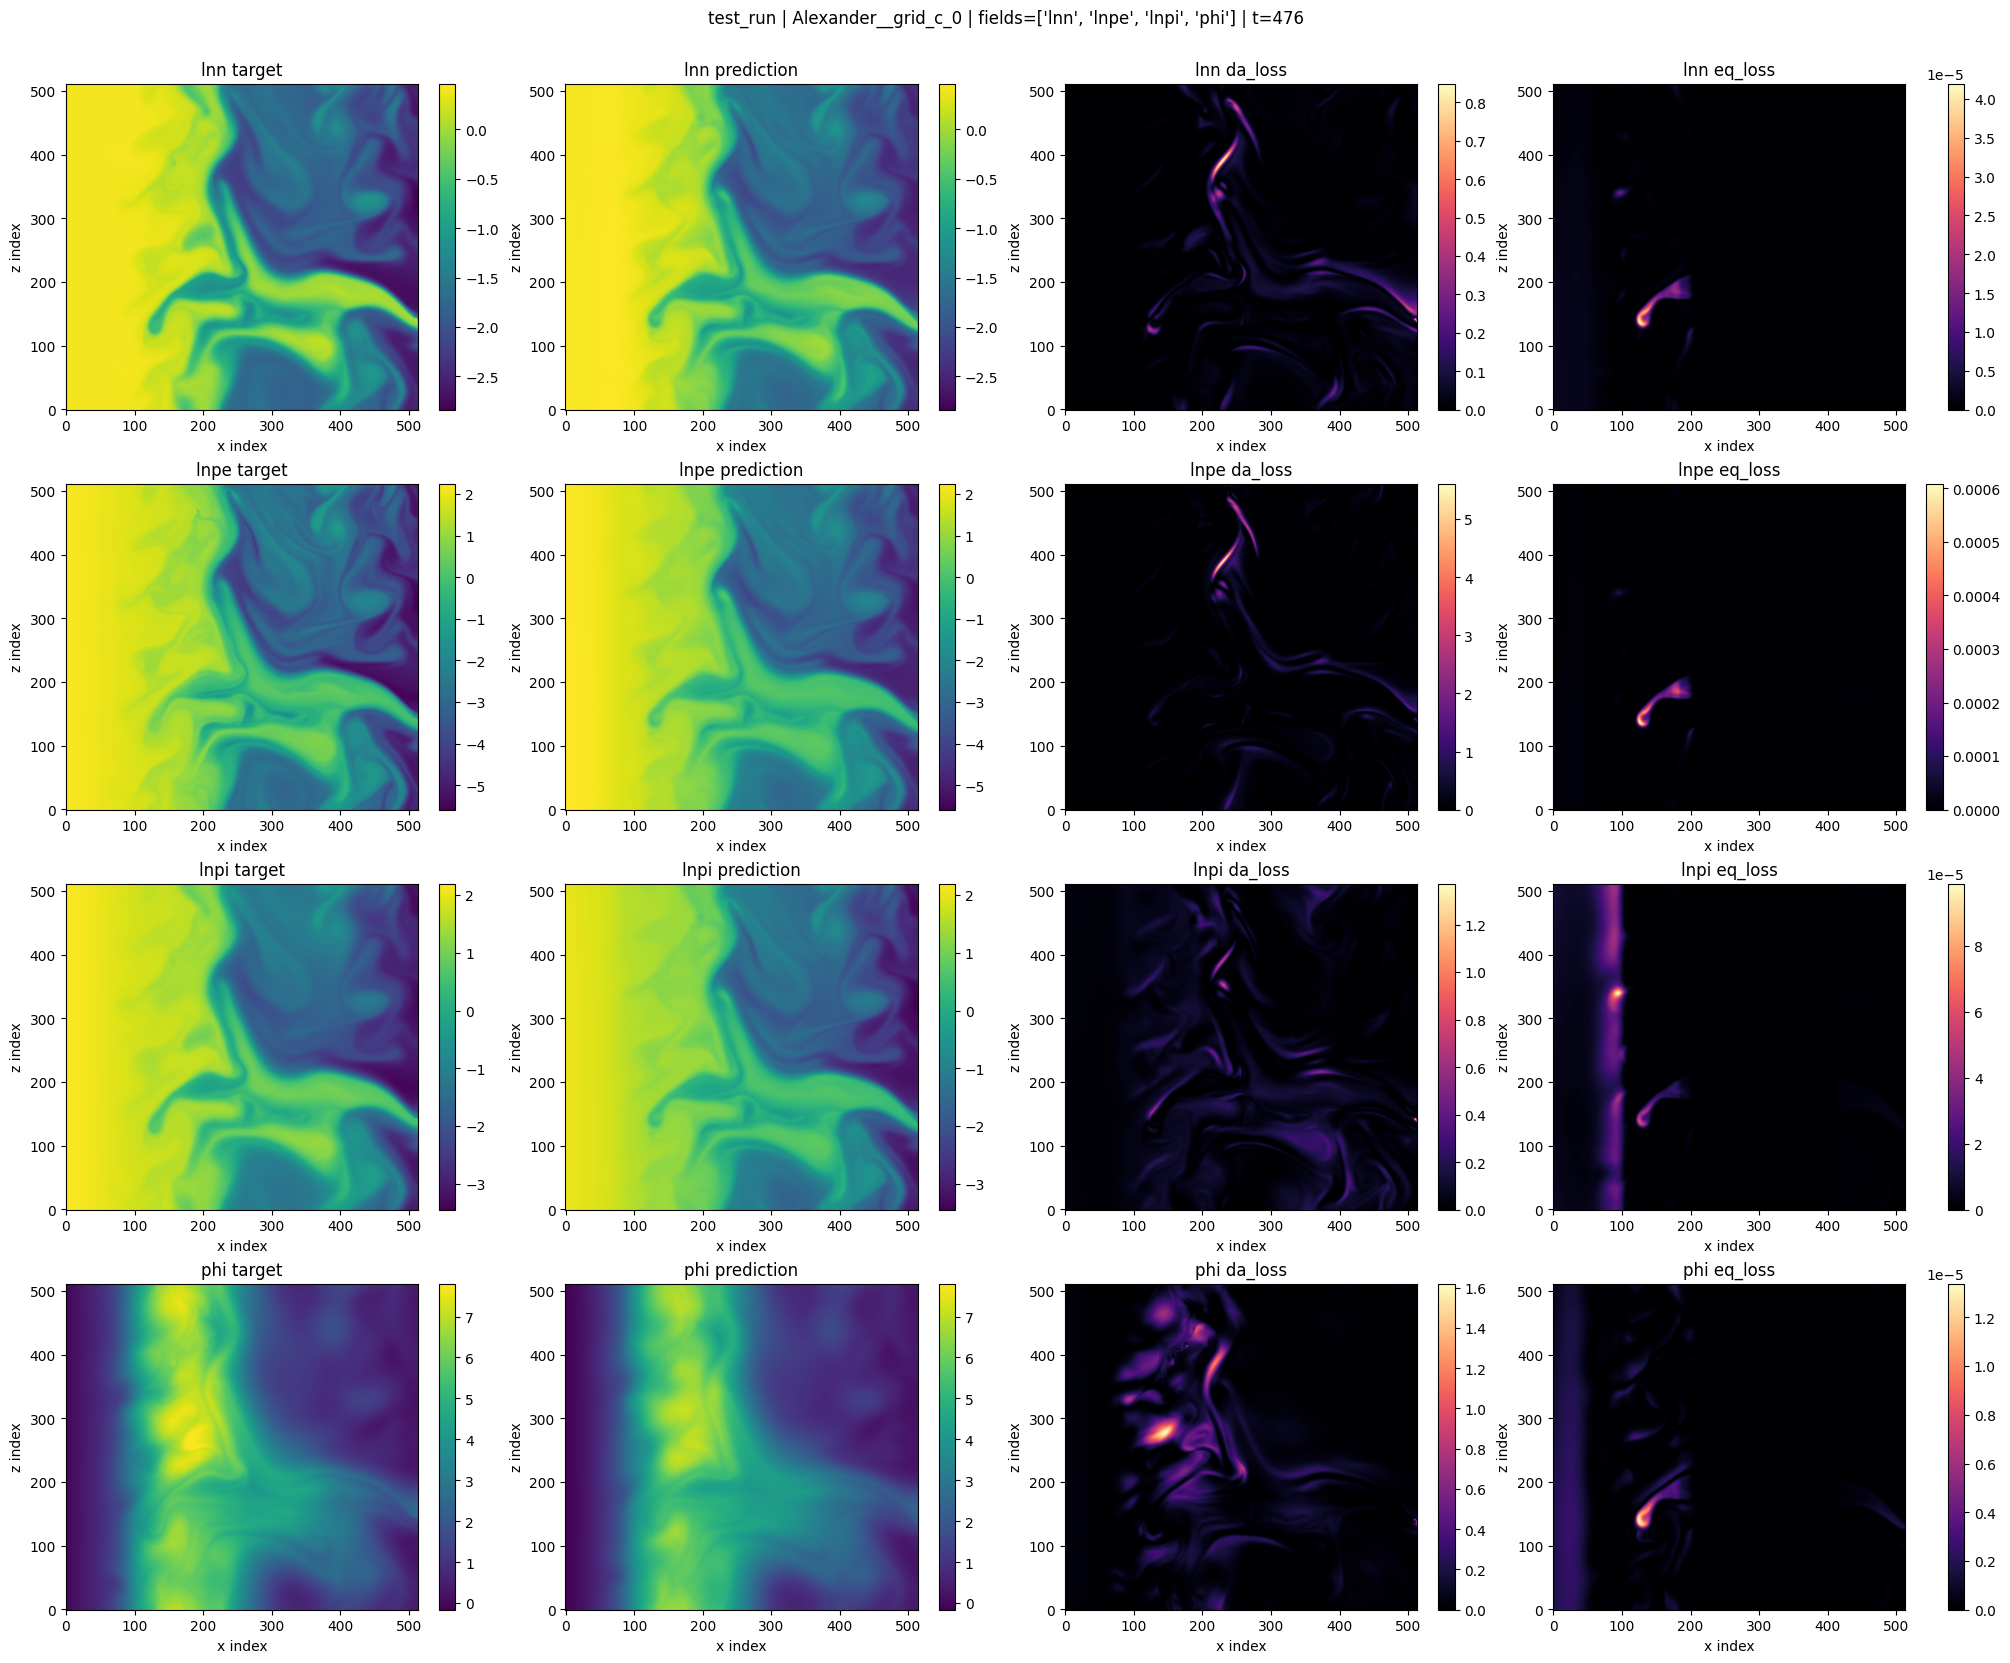

In [2]:
# Vaelg en model herfra:
MODEL_DIRS

MODEL_NAME = "test_run"
DATASET_ROOT = ROOT_DIR / "sim_data" / "Alexander__grid_c_0"  # None bruger checkpointets foerste root.
FIELDS_TO_PLOT = None  # None plotter alle fields. Fx ["lnn", "phi"] for et udvalg.
TARGET_T = 476
STATE_DICT_KEY = "model_state_dict"
EVAL_BATCH_SIZE = 2048

fig, axes, result = plot_full_image(
    checkpoint_dir=MODEL_DIRS[MODEL_NAME],
    dataset_root=DATASET_ROOT,
    fields=FIELDS_TO_PLOT,
    target_t=TARGET_T,
    state_dict_key=STATE_DICT_KEY,
    eval_batch_size=EVAL_BATCH_SIZE,
)
plt.show()
